<div style="display:flex; align-items:center; gap:18px; text-align:left">
  <img src="https://sebastiancontz.github.io/ust-diplomado-ia-curso-ml/assets/logo_ust.png" width="100">
  <div>
    <p>Diplomado en Inteligencia Artificial para los Negocios</p>
    <p>Facultad de Ingeniería y Negocios</p>
    <p>Módulo 2: Fundamentos de Machine Learning y herramientas Low Code</p>
    <p>Semana 07: Introducción a Forecasting</p>
  </div>
</div>

# 07 · Introducción a Forecasting

**Objetivo práctico:** pronosticar la demanda de pasajeros aéreos de Chile con **StatsForecast**, comparar modelos contra un *baseline* usando **validación temporal**, leer el pronóstico **con su incertidumbre** y traducirlo a una **decisión** de capacidad.

Datos **reales** de la **Junta de Aeronáutica Civil** (JAC, `datos.gob.cl`, licencia CC0): pasajeros mensuales de Chile, 2010–2025, en tres series: `total`, `nacional` e `internacional`.

## Preparación del entorno

Instalamos **StatsForecast** (forecasting) y utilidades de gráficos. Versiones pineadas para que corra igual en Colab.

In [1]:
%%capture
!pip install -q "statsforecast==2.0.3" "utilsforecast==0.2.15" plotly

## Setup técnico

Importaciones y configuración. Deja el entorno listo para concentrarnos en **interpretar y decidir**.

In [2]:
%matplotlib inline
import warnings, os
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mape

pd.options.display.float_format = '{:,.0f}'.format

## Cargar datos

En **Colab** los datos se leen del repo público; en local, desde `../datasets/`.

In [3]:
REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-fundamentos-machine-learning-colab/main/ediciones/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

df = pd.read_csv(BASE + 'trafico_aereo_cl.csv', parse_dates=['ds'])
print('Filas y columnas:', df.shape)
print('Series disponibles:', df['unique_id'].unique())
df.head()

Filas y columnas: (576, 3)
Series disponibles: ['internacional' 'nacional' 'total']


,unique_id,ds,y
0,internacional,2010-01-01,276185
1,internacional,2010-02-01,216808
2,internacional,2010-03-01,151591
3,internacional,2010-04-01,172548
4,internacional,2010-05-01,181973


## APIs de pandas que se incorporan

- `agg` resume cada grupo con varias estadísticas; `replace` cambia valores según una regla declarada.
- `to_datetime` convierte texto a fecha/hora y `DateOffset` desplaza fechas por un período explícito.

# 1. Cargar y explorar la serie

El formato de StatsForecast son tres columnas: `unique_id` (**qué serie**), `ds` (**cuándo**), `y` (**cuánto**). Antes de modelar, **miramos** la serie: tendencia, estacionalidad y quiebres.

In [4]:
resumen = df.groupby('unique_id').agg(desde=('ds','min'), hasta=('ds','max'),
                                      meses=('ds','size'), prom=('y','mean'))
resumen

,desde,hasta,meses,prom
unique_id,,,,
internacional,2010-01-01,2025-12-01,192,"334,175"
nacional,2010-01-01,2025-12-01,192,"462,563"
total,2010-01-01,2025-12-01,192,"796,738"


Visualicemos las tres series. Fíjate en la **tendencia**, la **estacionalidad** (cada enero sube) y el **quiebre** de 2020.

In [5]:
fig = px.line(df, x='ds', y='y', color='unique_id',
              labels={'ds':'Mes', 'y':'Pasajeros', 'unique_id':'Serie'},
              title='Pasajeros aéreos de Chile (JAC) — 2010 a 2025')
fig.update_layout(hovermode='x unified')
fig.show()

**Lo que vemos:** tendencia creciente hasta 2019; máximo cada **enero** (verano en Chile); y el **cambio estructural** de la pandemia en 2020 (mínimo en abril 2020), con recuperación. Ese quiebre es un aviso: el forecasting asume que el pasado se parece al futuro.

### Definir los modelos y el horizonte

Entrenamos **cuatro** modelos de una vez: **Naive** y **SeasonalNaive** (*baselines*), y **AutoETS** y **AutoARIMA** (estadísticos automáticos). El **horizonte** `h` = cuántos meses hacia adelante; elegimos **12**. `season_length=12` porque el ciclo es anual.

In [6]:
sf = StatsForecast(
    models=[Naive(), SeasonalNaive(season_length=12), AutoETS(season_length=12), AutoARIMA(season_length=12)],
    freq='MS', n_jobs=-1)

H = 12
modelos = ['Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA']

### Pronosticar el futuro (con incertidumbre)

`forecast` entrena y proyecta en una llamada. Pedimos **intervalos de predicción** del 80% y 95%: un pronóstico serio es un **rango**, no un número seco.

In [7]:
pronostico = sf.forecast(df=df, h=H, level=[80, 95])
pronostico[pronostico['unique_id'] == 'total'].head()

,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,...,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
24,total,2026-01-01,"1,289,107","1,150,646","1,077,348","1,427,568","1,500,866","1,454,958","1,102,385","915,744",...,"1,416,048","1,263,826","1,316,516","1,515,580","1,568,269","1,484,413","1,350,716","1,396,993","1,571,832","1,618,110"
25,total,2026-02-01,"1,289,107","1,093,293","989,635","1,484,921","1,588,579","1,324,346","971,773","785,132",...,"1,318,170","1,104,570","1,178,504","1,457,836","1,531,770","1,365,075","1,143,276","1,220,048","1,510,102","1,586,874"
26,total,2026-03-01,"1,289,107","1,049,285","922,330","1,528,929","1,655,884","1,242,552","889,979","703,338",...,"1,194,753","933,834","1,024,147","1,365,358","1,455,672","1,245,054","973,938","1,067,781","1,422,328","1,516,170"
27,total,2026-04-01,"1,289,107","1,012,184","865,590","1,566,030","1,712,624","1,063,261","710,688","524,047",...,"1,036,988","736,102","840,250","1,233,727","1,337,875","1,108,836","799,288","906,434","1,311,238","1,418,383"
28,total,2026-05-01,"1,289,107","979,498","815,600","1,598,716","1,762,614","1,045,397","692,824","506,183",...,"1,071,887","735,753","852,101","1,291,674","1,408,022","1,104,940","761,470","880,357","1,329,522","1,448,409"


Grafiquemos la serie `total`: historia + pronóstico de **AutoETS** con sus bandas. Fíjate cómo **se ensanchan** hacia el futuro: la incertidumbre se acumula.

> **La IA como copiloto (opcional).** Si prefieres no escribir el código del gráfico, puedes pedírselo a una IA (ChatGPT, Claude, Gemini) con un prompt como este:
>
> *"Tengo dos DataFrames de pandas. `df` tiene la historia con columnas `unique_id`, `ds` (fecha) e `y` (pasajeros). `pronostico` es la salida de StatsForecast, con columnas `unique_id`, `ds`, `AutoETS` y los intervalos `AutoETS-lo-80`, `AutoETS-hi-80`, `AutoETS-lo-95`, `AutoETS-hi-95`. Con matplotlib, grafica solo la serie `total`: la historia en gris, la línea de pronóstico de AutoETS, y sus intervalos del 80% y 95% como bandas sombreadas que se abren hacia el futuro. Título y etiquetas del eje en español, y leyenda arriba a la izquierda."*
>
> **Revisa siempre lo que te devuelve:** que use las columnas correctas y que las bandas sean del 80% y 95%. La IA acelera el "cómo"; el criterio de qué mostrar y cómo leerlo sigue siendo tuyo.

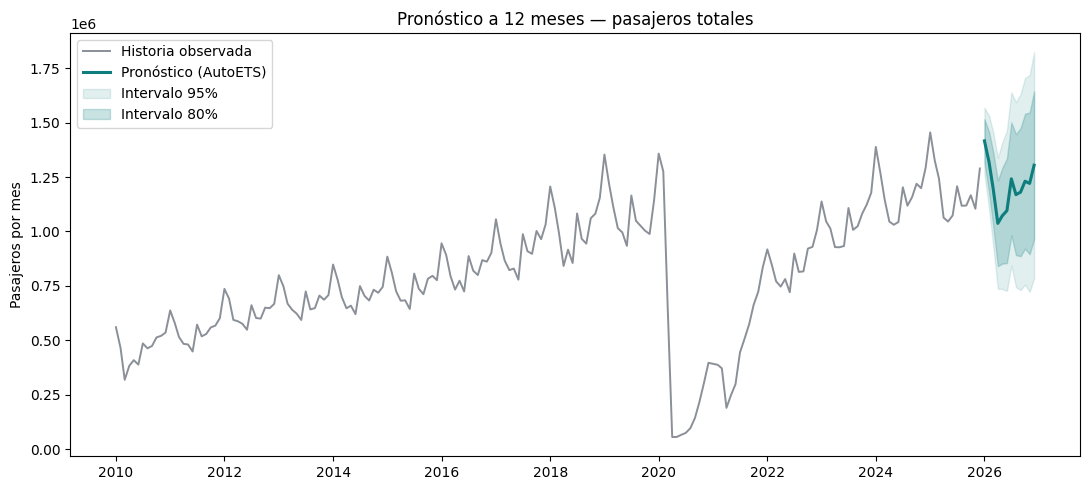

In [8]:
hist = df[df['unique_id'] == 'total']
fc = pronostico[pronostico['unique_id'] == 'total']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hist['ds'], hist['y'], color='#8a8f98', lw=1.4, label='Historia observada')
ax.plot(fc['ds'], fc['AutoETS'], color='#0d7d7d', lw=2.2, label='Pronóstico (AutoETS)')
ax.fill_between(fc['ds'], fc['AutoETS-lo-95'], fc['AutoETS-hi-95'], color='#0d7d7d', alpha=0.12, label='Intervalo 95%')
ax.fill_between(fc['ds'], fc['AutoETS-lo-80'], fc['AutoETS-hi-80'], color='#0d7d7d', alpha=0.22, label='Intervalo 80%')
ax.set_title('Pronóstico a 12 meses — pasajeros totales'); ax.set_ylabel('Pasajeros por mes')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

**Cómo leerlo para decidir:** la línea central es lo más probable; la banda del 95% es el rango honesto. Si quedarse corto es caro, se mira el **límite superior**.

# 2. Revisémoslo juntos

¿Cuál modelo es mejor? Lo sabemos con **validación temporal**: nos "paramos" en el pasado, pronosticamos los meses siguientes, comparamos con lo que ocurrió, y repetimos desde varios puntos. **Nunca** se baraja.

In [9]:
cv = sf.cross_validation(df=df, h=H, n_windows=3, step_size=12)
cv.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,internacional,2023-01-01,2022-12-01,"453,257","395,808","248,730","434,258","403,570"
1,internacional,2023-02-01,2022-12-01,"407,640","395,808","218,219","389,295","383,920"
2,internacional,2023-03-01,2022-12-01,"382,609","395,808","229,362","335,384","388,435"
3,internacional,2023-04-01,2022-12-01,"361,157","395,808","252,537","286,734","389,198"
4,internacional,2023-05-01,2022-12-01,"351,068","395,808","271,329","303,630","398,615"


### Ver las ventanas de validación

Cada **corte** (`cutoff`) marca dónde termina el pasado y empieza el futuro de esa prueba. Veámoslos sobre la serie total:

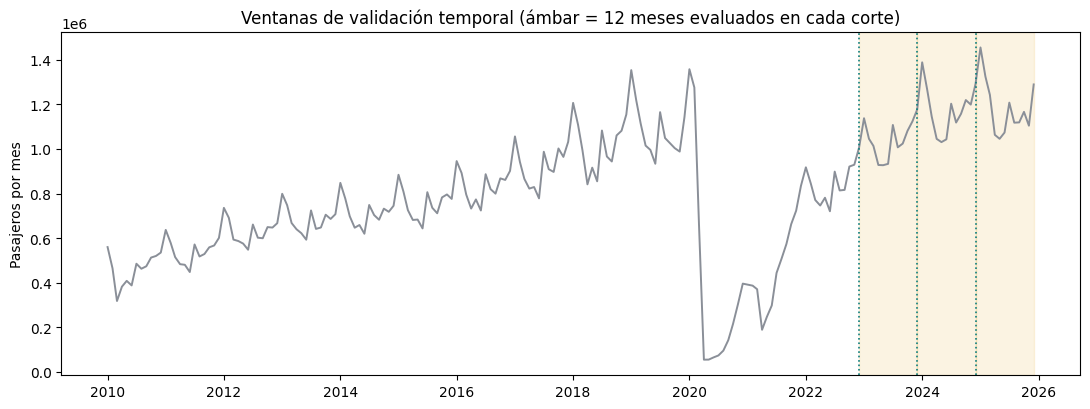

Cortes (cutoffs): ['2022-12', '2023-12', '2024-12']


In [10]:
tot_s = df[df['unique_id'] == 'total'].set_index('ds')['y']
cortes = sorted(pd.to_datetime(cv['cutoff'].unique()))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(tot_s.index, tot_s.values, color='#8a8f98', lw=1.4)
for co in cortes:
    ax.axvline(co, color='#0d7d7d', ls=':', lw=1.2)
    ax.axvspan(co, co + pd.DateOffset(months=12), color='#e6a417', alpha=0.12)
ax.set_title('Ventanas de validación temporal (ámbar = 12 meses evaluados en cada corte)')
ax.set_ylabel('Pasajeros por mes'); plt.tight_layout(); plt.show()

print('Cortes (cutoffs):', [c.strftime('%Y-%m') for c in cortes])

> **Ojo (qué período estamos evaluando):** con 3 ventanas de 12 meses, los cortes caen a fines de 2022, 2023 y 2024, así que evaluamos **2023, 2024 y 2025** — es decir, sobre todo el período **posterior al quiebre COVID** (la recuperación). El desempeño que medimos es representativo de esa etapa, no de 2020.

### El error por modelo

Con el resultado de la validación, medimos el error. **MAE** en la unidad (pasajeros) y **MAPE** en porcentaje.

In [11]:
ev = evaluate(cv.drop(columns='cutoff'), metrics=[mae, mape], models=modelos)

# El MAPE viene en fracción (0.08); lo pasamos a porcentaje para leerlo bien.
ev.loc[ev['metric'] == 'mape', modelos] *= 100
ev['metric'] = ev['metric'].replace({'mape': 'mape (%)'})
ev

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,internacional,mae,"46,052","78,606","51,294","22,511"
1,nacional,mae,"61,201","48,882","37,023","66,096"
2,total,mae,"100,209","122,792","81,732","142,587"
3,internacional,mape (%),10,17,11,5
4,nacional,mape (%),9,7,6,10
5,total,mape (%),9,11,8,13


> **Cuidado con el MAPE:** divide por el valor real, así que se vuelve **inestable con ceros o valores cercanos a cero** (una serie con muchos ceros puede dar MAPE enorme o indefinido). En esos casos, guíate por el **MAE**.

In [12]:
resumen_error = ev.groupby('metric')[modelos].mean()
resumen_error

,Naive,SeasonalNaive,AutoETS,AutoARIMA
metric,,,,
mae,"69,154","83,427","56,683","77,064"
mape (%),9,12,8,9


**Cómo interpretar (decidir por serie, no por el promedio):**

- El promedio global es solo una **referencia rápida**; la decisión se toma **por serie**, porque el ganador cambia de una a otra.
- En la serie **`total`**, el humilde **Naive** es difícil de batir y SeasonalNaive/AutoARIMA quedan **peor** que él: el quiebre 2020 rompió el patrón año-a-año. En **internacional** suele ganar AutoARIMA.
- Regla: un modelo **solo aporta si le gana al *baseline*** (Naive) en esta validación honesta.

**Del error a la decisión — pronóstico, meta y plan (no son lo mismo):**

- **Pronóstico:** lo que los datos dicen que probablemente pasará (p. ej. ~1,42M en enero).
- **Meta:** lo que el negocio quiere que pase (p. ej. +5%).
- **Plan:** las acciones para acercar el pronóstico a la meta (rutas, tarifas, campañas).

# 3. Ahora tú

Repite el análisis para **otra serie**, ajustando el horizonte y las ventanas, genera el **pronóstico con intervalos** y **decide**.

1. Ajusta `serie`, `horizonte` y `n_windows`.
2. Valida en el tiempo → elige el modelo ganador **de esa serie**.
3. Genera y **grafica** el pronóstico con sus intervalos.
4. Completa la **plantilla de decisión de negocio**.

In [13]:
# --- Ajusta estos tres valores ---
serie     = 'nacional'     # 'nacional' o 'internacional'
horizonte = 12             # meses a pronosticar (prueba 6, 12, 18...)
n_windows = 3              # ventanas de validación temporal

df_serie = df[df['unique_id'] == serie]

# (a) validación temporal -> error por modelo
cv_s = sf.cross_validation(df=df_serie, h=horizonte, n_windows=n_windows, step_size=12)
ev_s = evaluate(cv_s.drop(columns='cutoff'), metrics=[mae, mape], models=modelos)
ev_s.loc[ev_s['metric'] == 'mape', modelos] *= 100
ev_s['metric'] = ev_s['metric'].replace({'mape': 'mape (%)'})
ev_s

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,nacional,mae,"61,201","48,882","37,023","66,096"
1,nacional,mape (%),9,7,6,10


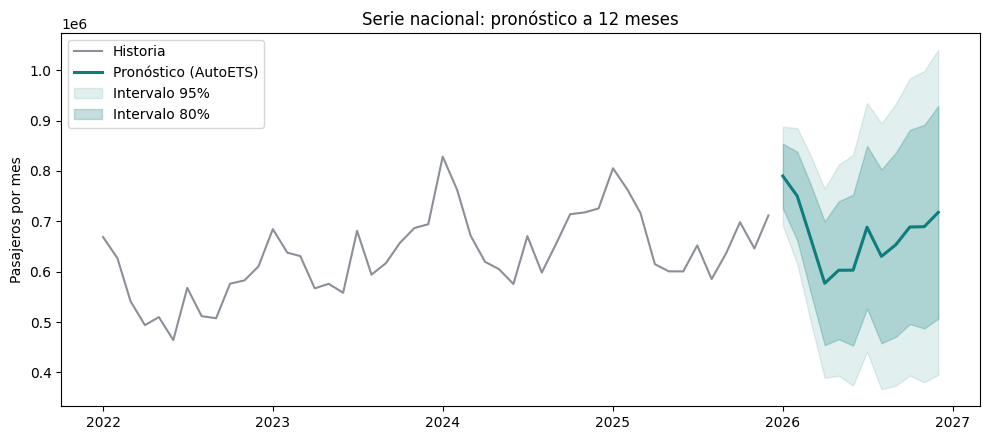

Primer mes pronosticado con AutoETS:
  central     : 789,907 pasajeros
  intervalo 95%: [ 691,892 , 887,922 ]


In [14]:
# (b) pronóstico con intervalos + gráfico
modelo = 'AutoETS'         # cámbialo por el ganador de tu tabla de arriba

fc_s = sf.forecast(df=df_serie, h=horizonte, level=[80, 95])
hist_s = df_serie.set_index('ds')['y']
f_s = fc_s.set_index('ds')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(hist_s.index[-48:], hist_s.values[-48:], color='#8a8f98', lw=1.5, label='Historia')
ax.plot(f_s.index, f_s[modelo], color='#0d7d7d', lw=2.2, label='Pronóstico (' + modelo + ')')
ax.fill_between(f_s.index, f_s[modelo + '-lo-95'], f_s[modelo + '-hi-95'], color='#0d7d7d', alpha=0.12, label='Intervalo 95%')
ax.fill_between(f_s.index, f_s[modelo + '-lo-80'], f_s[modelo + '-hi-80'], color='#0d7d7d', alpha=0.24, label='Intervalo 80%')
ax.set_title('Serie ' + serie + ': pronóstico a ' + str(horizonte) + ' meses'); ax.set_ylabel('Pasajeros por mes')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

# valores del primer mes pronosticado (para tu decisión)
prim = f_s.iloc[0]
print('Primer mes pronosticado con', modelo + ':')
print('  central     :', format(prim[modelo], ',.0f'), 'pasajeros')
print('  intervalo 95%: [', format(prim[modelo + '-lo-95'], ',.0f'), ',', format(prim[modelo + '-hi-95'], ',.0f'), ']')

**Tu decisión de negocio** (completa esta plantilla en esta celda de texto):

- **Modelo elegido:** …
- **Pronóstico central (primer mes):** … pasajeros
- **Intervalo 95%:** entre … y … pasajeros
- **Costo de subestimar:** …
- **Costo de sobreestimar:** …
- **Decisión recomendada:** … *(¿cerca del centro, del techo o del piso del intervalo? ¿por qué?)*
- **Limitación / riesgo del pronóstico:** …

## Cierre

- **Qué aprendimos:** pronosticar una serie real con StatsForecast (baselines + modelos automáticos), validar **respetando el tiempo** y comparar con MAE/MAPE contra un *baseline*.
- **Qué decisión permite:** estimar la demanda futura **con su incertidumbre** para planificar capacidad, con un colchón acorde al costo de quedarse corto.
- **Qué límites comunicar:** el pronóstico asume que el pasado se parece al futuro; un **quiebre** (2020) lo invalida. Y no toda serie se pronostica igual: un precio financiero es casi ruido — **pronosticar no es recomendar invertir**.

## Atribución de datos

**Creador:** Junta de Aeronáutica Civil de Chile y Coordinador Eléctrico Nacional.
**Fuente:** [Tráfico Aéreo de la JAC](https://datos.gob.cl/dataset/trafico-aereo) y [API pública SIP del Coordinador](https://sipub.api.coordinador.cl/api/v2/recursos/demanda_sistema_real/).
**Licencia:** tráfico JAC bajo [CC0](https://creativecommons.org/publicdomain/zero/1.0/); la API SIP no declara una licencia abierta en su [documentación](https://sipub.api.coordinador.cl/).
**Modificación:** tráfico agregado a series mensuales; demanda extraída para 2025 y conservada como caso operativo de alta frecuencia.